In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/abhi8923shriv/sentiment-analysis-dataset/training.1600000.processed.noemoticon.csv
/kaggle/input/datasets/abhi8923shriv/sentiment-analysis-dataset/train.csv
/kaggle/input/datasets/abhi8923shriv/sentiment-analysis-dataset/testdata.manual.2009.06.14.csv
/kaggle/input/datasets/abhi8923shriv/sentiment-analysis-dataset/test.csv


# Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
import re
import warnings
warnings.filterwarnings('ignore')


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

2026-05-11 08:58:11.505777: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778489891.843405      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778489891.925220      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778489892.689271      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778489892.689353      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778489892.689357      16 computation_placer.cc:177] computation placer alr

/kaggle/input/datasets/abhi8923shriv/sentiment-analysis-dataset/training.1600000.processed.noemoticon.csv
/kaggle/input/datasets/abhi8923shriv/sentiment-analysis-dataset/train.csv
/kaggle/input/datasets/abhi8923shriv/sentiment-analysis-dataset/testdata.manual.2009.06.14.csv
/kaggle/input/datasets/abhi8923shriv/sentiment-analysis-dataset/test.csv


# Load Dataset
"If you face any issues while loadind the dataset, you can use (**encoding = 'latin1')**  

"The error occurs because tweets sometimes contain special characters that prevent the file from being read correctly , which is why we need this code


In [3]:
df = pd.read_csv('/kaggle/input/datasets/abhi8923shriv/sentiment-analysis-dataset/train.csv',encoding = 'latin1')
df

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26
...,...,...,...,...,...,...,...,...,...,...
27476,4eac33d1c0,wish we could come see u on Denver husband l...,d lost,negative,night,31-45,Ghana,31072940,227540.0,137
27477,4f4c4fc327,I`ve wondered about rake to. The client has ...,", don`t force",negative,morning,46-60,Greece,10423054,128900.0,81
27478,f67aae2310,Yay good for both of you. Enjoy the break - y...,Yay good for both of you.,positive,noon,60-70,Grenada,112523,340.0,331
27479,ed167662a5,But it was worth it ****.,But it was worth it ****.,positive,night,70-100,Guatemala,17915568,107160.0,167


In [4]:
df.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [5]:
df.info

<bound method DataFrame.info of            textID                                               text  \
0      cb774db0d1                I`d have responded, if I were going   
1      549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2      088c60f138                          my boss is bullying me...   
3      9642c003ef                     what interview! leave me alone   
4      358bd9e861   Sons of ****, why couldn`t they put them on t...   
...           ...                                                ...   
27476  4eac33d1c0   wish we could come see u on Denver  husband l...   
27477  4f4c4fc327   I`ve wondered about rake to.  The client has ...   
27478  f67aae2310   Yay good for both of you. Enjoy the break - y...   
27479  ed167662a5                         But it was worth it  ****.   
27480  6f7127d9d7     All this flirting going on - The ATG smiles...   

                                           selected_text sentiment  \
0                    I`d have res

In [6]:
df.describe()

,Population -2020,Land Area (Km²),Density (P/Km²)
count,2.748100e+04,2.748100e+04,27481.000000
mean,4.018497e+07,6.621730e+05,357.686583
std,1.504946e+08,1.807425e+06,2013.750702
min,8.010000e+02,0.000000e+00,2.000000
25%,1.968001e+06,2.281000e+04,35.000000
50%,8.655535e+06,1.118900e+05,89.000000
75%,2.843594e+07,5.279700e+05,214.000000
max,1.439324e+09,1.637687e+07,26337.000000


In [7]:
df.columns

Index(['textID', 'text', 'selected_text', 'sentiment', 'Time of Tweet',
       'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)',
       'Density (P/Km²)'],
      dtype='object')

In [8]:
df.shape

(27481, 10)

In [9]:
df.nunique

<bound method DataFrame.nunique of            textID                                               text  \
0      cb774db0d1                I`d have responded, if I were going   
1      549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2      088c60f138                          my boss is bullying me...   
3      9642c003ef                     what interview! leave me alone   
4      358bd9e861   Sons of ****, why couldn`t they put them on t...   
...           ...                                                ...   
27476  4eac33d1c0   wish we could come see u on Denver  husband l...   
27477  4f4c4fc327   I`ve wondered about rake to.  The client has ...   
27478  f67aae2310   Yay good for both of you. Enjoy the break - y...   
27479  ed167662a5                         But it was worth it  ****.   
27480  6f7127d9d7     All this flirting going on - The ATG smiles...   

                                           selected_text sentiment  \
0                    I`d have 

In [10]:
df.isna().sum

<bound method DataFrame.sum of        textID   text  selected_text  sentiment  Time of Tweet  Age of User  \
0       False  False          False      False          False        False   
1       False  False          False      False          False        False   
2       False  False          False      False          False        False   
3       False  False          False      False          False        False   
4       False  False          False      False          False        False   
...       ...    ...            ...        ...            ...          ...   
27476   False  False          False      False          False        False   
27477   False  False          False      False          False        False   
27478   False  False          False      False          False        False   
27479   False  False          False      False          False        False   
27480   False  False          False      False          False        False   

       Country  Population -2020

# Exploratory Data Analysis(EDA)

<function matplotlib.pyplot.show(close=None, block=None)>

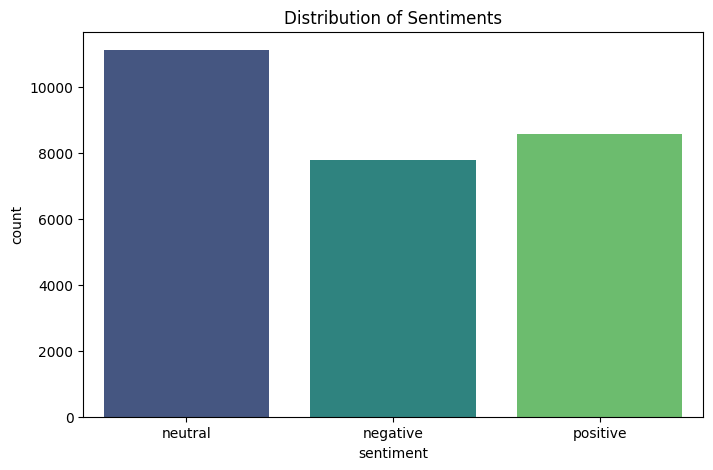

In [11]:
# 1. Sentiment Distribution

plt.figure(figsize = (8,5))
sns.countplot(x = 'sentiment',data = df, palette = 'viridis')
plt.title('Distribution of Sentiments')
plt.show

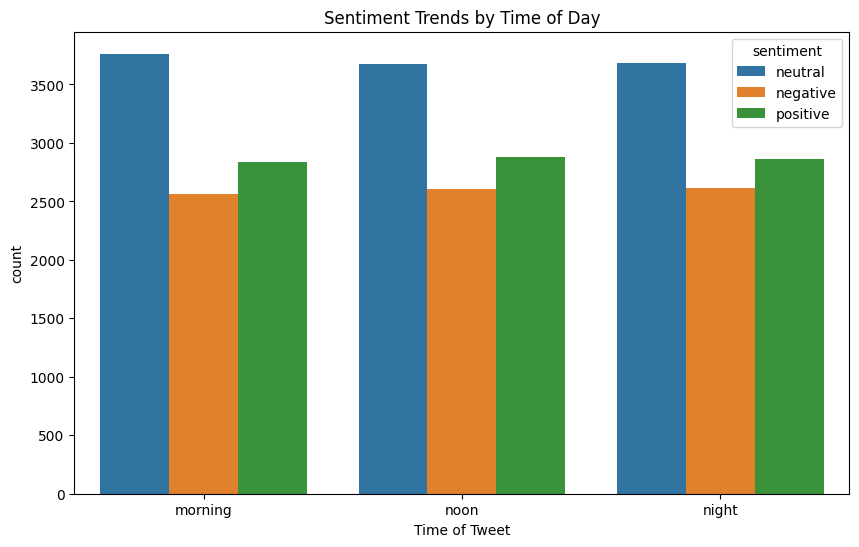

In [12]:
# 2. Sentiment by time of Day
# This helps see if people are crankier at night or happier in the morning
plt.figure(figsize = (10,6))
sns.countplot(x = 'Time of Tweet',hue = 'sentiment',data = df)
plt.title('Sentiment Trends by Time of Day')
plt.show()

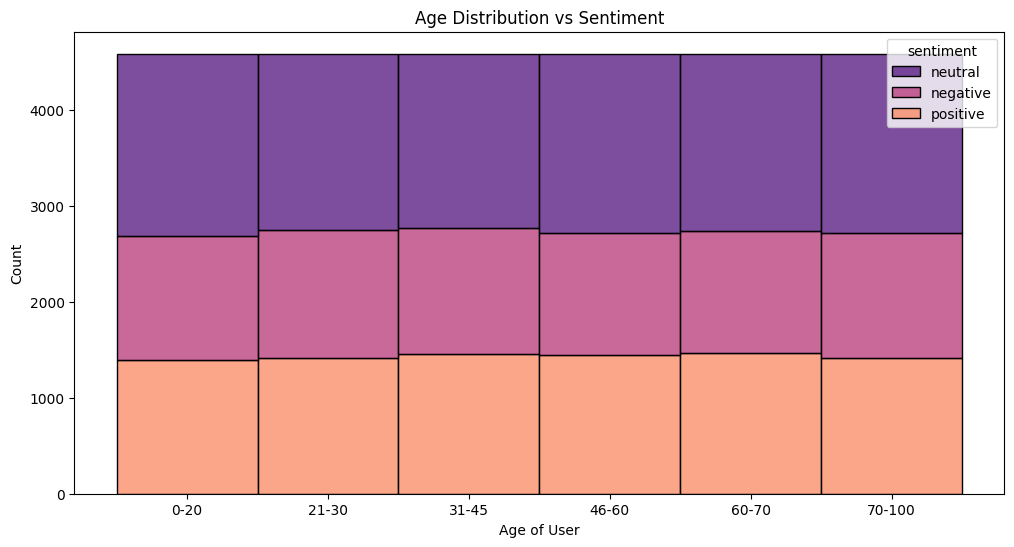

In [13]:
# 3. Sentiment by Age Group
# We can bin the agesto see which generation is most positive/negative

plt.figure(figsize = (12 , 6))
sns.histplot(data = df , x = 'Age of User',hue = 'sentiment',multiple = "stack", palette = 'magma')
plt.title('Age Distribution vs Sentiment')
plt.show()

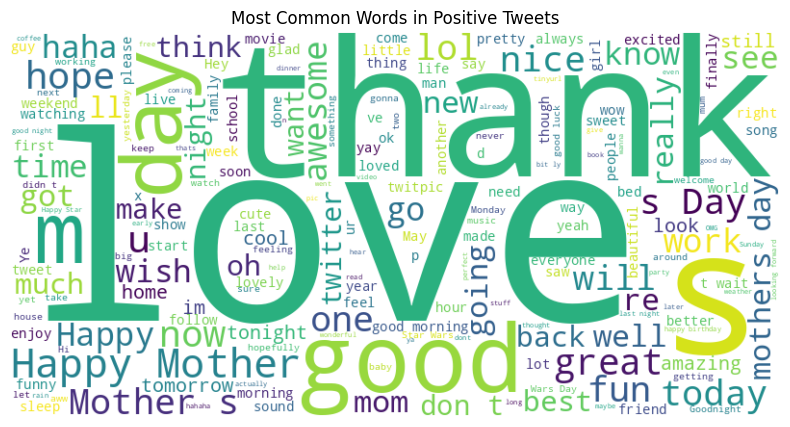

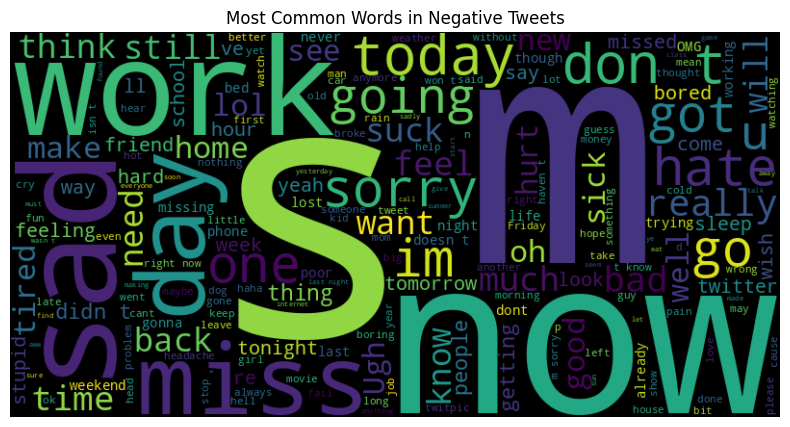

In [14]:
# 4. Word Clouds for Positive vs Negative
# This visually highlights the "impact words" in your dataset

def plot_wordcloud(sentiment_type, color):
    # 1. Gather all text for the specific sentiment
    text = " ".join(t for t in df[df['sentiment']==sentiment_type]['text'].astype(str))
    
    # 2. Generate the wordcloud 
    # FIX: Changed 'Color' to 'color' (lowercase) to match the function definition
    wordcloud = WordCloud(background_color = color, width = 800, height = 400).generate(text)
    
    # 3. Plot the result
    plt.figure(figsize = (10, 5))
    plt.imshow(wordcloud, interpolation = 'bilinear')
    plt.axis("off")
    plt.title(f'Most Common Words in {sentiment_type.capitalize()} Tweets')
    plt.show()

# 4. Call the functions
plot_wordcloud("positive", "white")
plot_wordcloud("negative", "black")

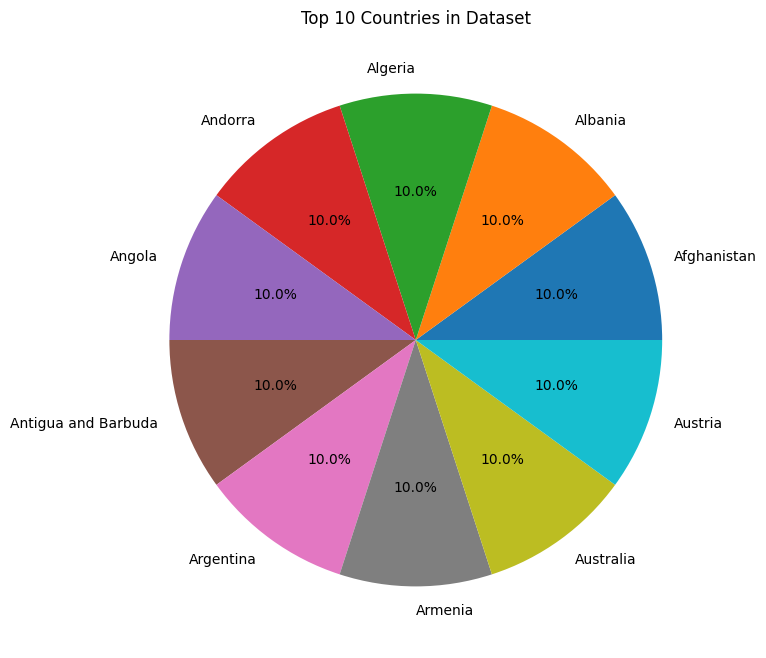

In [15]:
# 5. Top 10 Countries contributing to the dataset
plt.figure(figsize=(10, 8))
df['Country'].value_counts().head(10).plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 10 Countries in Dataset')
plt.ylabel('')
plt.show()

# Preprocessing the Data

In [16]:
# 1. TEXT CLEANING
def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # URLs
    text = re.sub(r'\@\w+|\#','', text) # Mentions/Hashtags
    text = re.sub(r'[^\w\s]', '', text) # Punctuation
    return text

df['clean_text'] = df['text'].apply(clean_tweet)


In [17]:
# 2. LABEL ENCODING (Convert sentiment to 0, 1, 2)
le = LabelEncoder()
df['target'] = le.fit_transform(df['sentiment']) 
# Usually: 0=negative, 1=neutral, 2=positive

In [18]:
# 3. TOKENIZATION & PADDING
max_features = 5000 # Top words to keep
tokenizer = Tokenizer(num_words=max_features, split=' ')
tokenizer.fit_on_texts(df['clean_text'].values)

X = tokenizer.texts_to_sequences(df['clean_text'].values)
X = pad_sequences(X, maxlen=50) # Ensure all tweets are same length
y = pd.get_dummies(df['target']).values # One-hot encoding for the model


In [19]:
# 4. TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [20]:
# 5. BUILD LSTM MODEL
model = Sequential()
model.add(Embedding(max_features, 128, input_length=X.shape[1]))
model.add(SpatialDropout1D(0.4))
model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(3, activation='softmax')) # 3 because we have neg, neut, pos

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


2026-05-11 08:58:48.575149: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [21]:
# 6. TRAIN
print("Starting training...")
batch_size = 32
history = model.fit(X_train, y_train, epochs=5, batch_size=batch_size, validation_data=(X_test, y_test), verbose=1)

Starting training...
Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 53s 71ms/step - accuracy: 0.5244 - loss: 0.9533 - val_accuracy: 0.7006 - val_loss: 0.7184
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 48s 71ms/step - accuracy: 0.7359 - loss: 0.6473 - val_accuracy: 0.7084 - val_loss: 0.6901
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 48s 70ms/step - accuracy: 0.7709 - loss: 0.5698 - val_accuracy: 0.7086 - val_loss: 0.6939
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 48s 69ms/step - accuracy: 0.8028 - loss: 0.5042 - val_accuracy: 0.7149 - val_loss: 0.6991
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 48s 70ms/step - accuracy: 0.8159 - loss: 0.4784 - val_accuracy: 0.7149 - val_loss: 0.7176


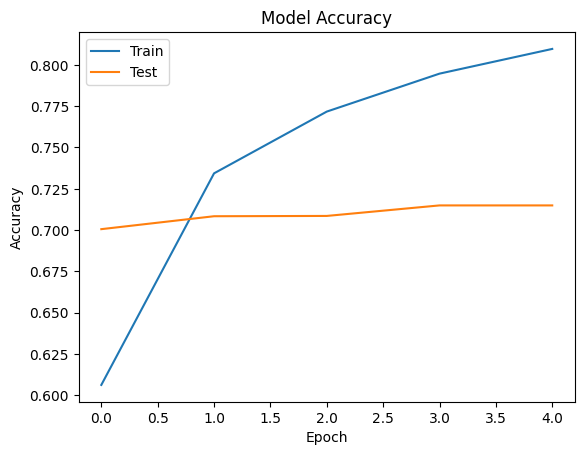

In [22]:
# 7. VISUALIZE RESULTS
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Model Evaluation : Confusion Matrix

172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step


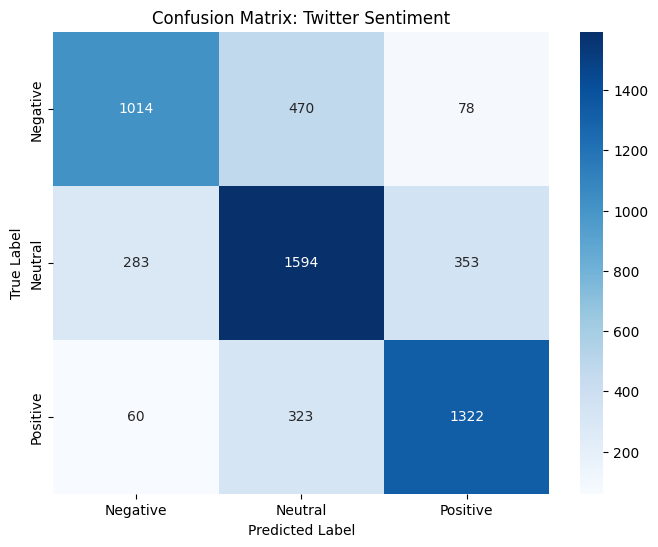

              precision    recall  f1-score   support

    Negative       0.75      0.65      0.69      1562
     Neutral       0.67      0.71      0.69      2230
    Positive       0.75      0.78      0.76      1705

    accuracy                           0.71      5497
   macro avg       0.72      0.71      0.72      5497
weighted avg       0.72      0.71      0.71      5497



In [23]:
from sklearn.metrics import confusion_matrix,classification_report

# 1. Get predictions (probabilities)
y_pred_probs = model.predict(X_test)

# 2. Convert probabilities to class indices (0, 1, or 2)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Convert true labels (y_test) if they are currently one-hot encoded
if len(y_test.shape) > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

# 4. Generate the Confusion Matrix
labels = ['Negative', 'Neutral', 'Positive']
cm = confusion_matrix(y_true, y_pred)

# 5. Plot using Seaborn Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: Twitter Sentiment')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 6. Detailed Performance Report
print(classification_report(y_true, y_pred, target_names=labels))